In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

%matplotlib inline

In [11]:
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv('processed.cleveland.data', names=columns, na_values='?')

df = df.dropna()

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("Dataset Dimensions:", df.shape)
print("\nTarget Class Distribution:\n", df['target'].value_counts(normalize=True))
df.head()

Dataset Dimensions: (297, 14)

Target Class Distribution:
 target
0    0.538721
1    0.461279
Name: proportion, dtype: float64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [12]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (237, 13)
Testing Features Shape: (60, 13)


In [5]:
base_dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
base_dt.fit(X_train, y_train)

base_pred = base_dt.predict(X_test)
print(f"Baseline Model Accuracy: {accuracy_score(y_test, base_pred):.2%}")

Baseline Model Accuracy: 76.67%


In [6]:
param_grid = {
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(criterion='entropy', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_dt_model = grid_search.best_estimator_

print("Optimal Hyperparameters:", grid_search.best_params_)

Optimal Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


Optimized Model Accuracy: 76.67%

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.79        32
           1       0.77      0.71      0.74        28

    accuracy                           0.77        60
   macro avg       0.77      0.76      0.76        60
weighted avg       0.77      0.77      0.77        60



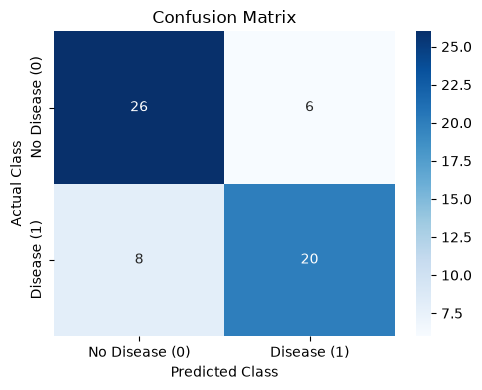

In [7]:
y_pred = best_dt_model.predict(X_test)

print(f"Optimized Model Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease (0)', 'Disease (1)'], 
            yticklabels=['No Disease (0)', 'Disease (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

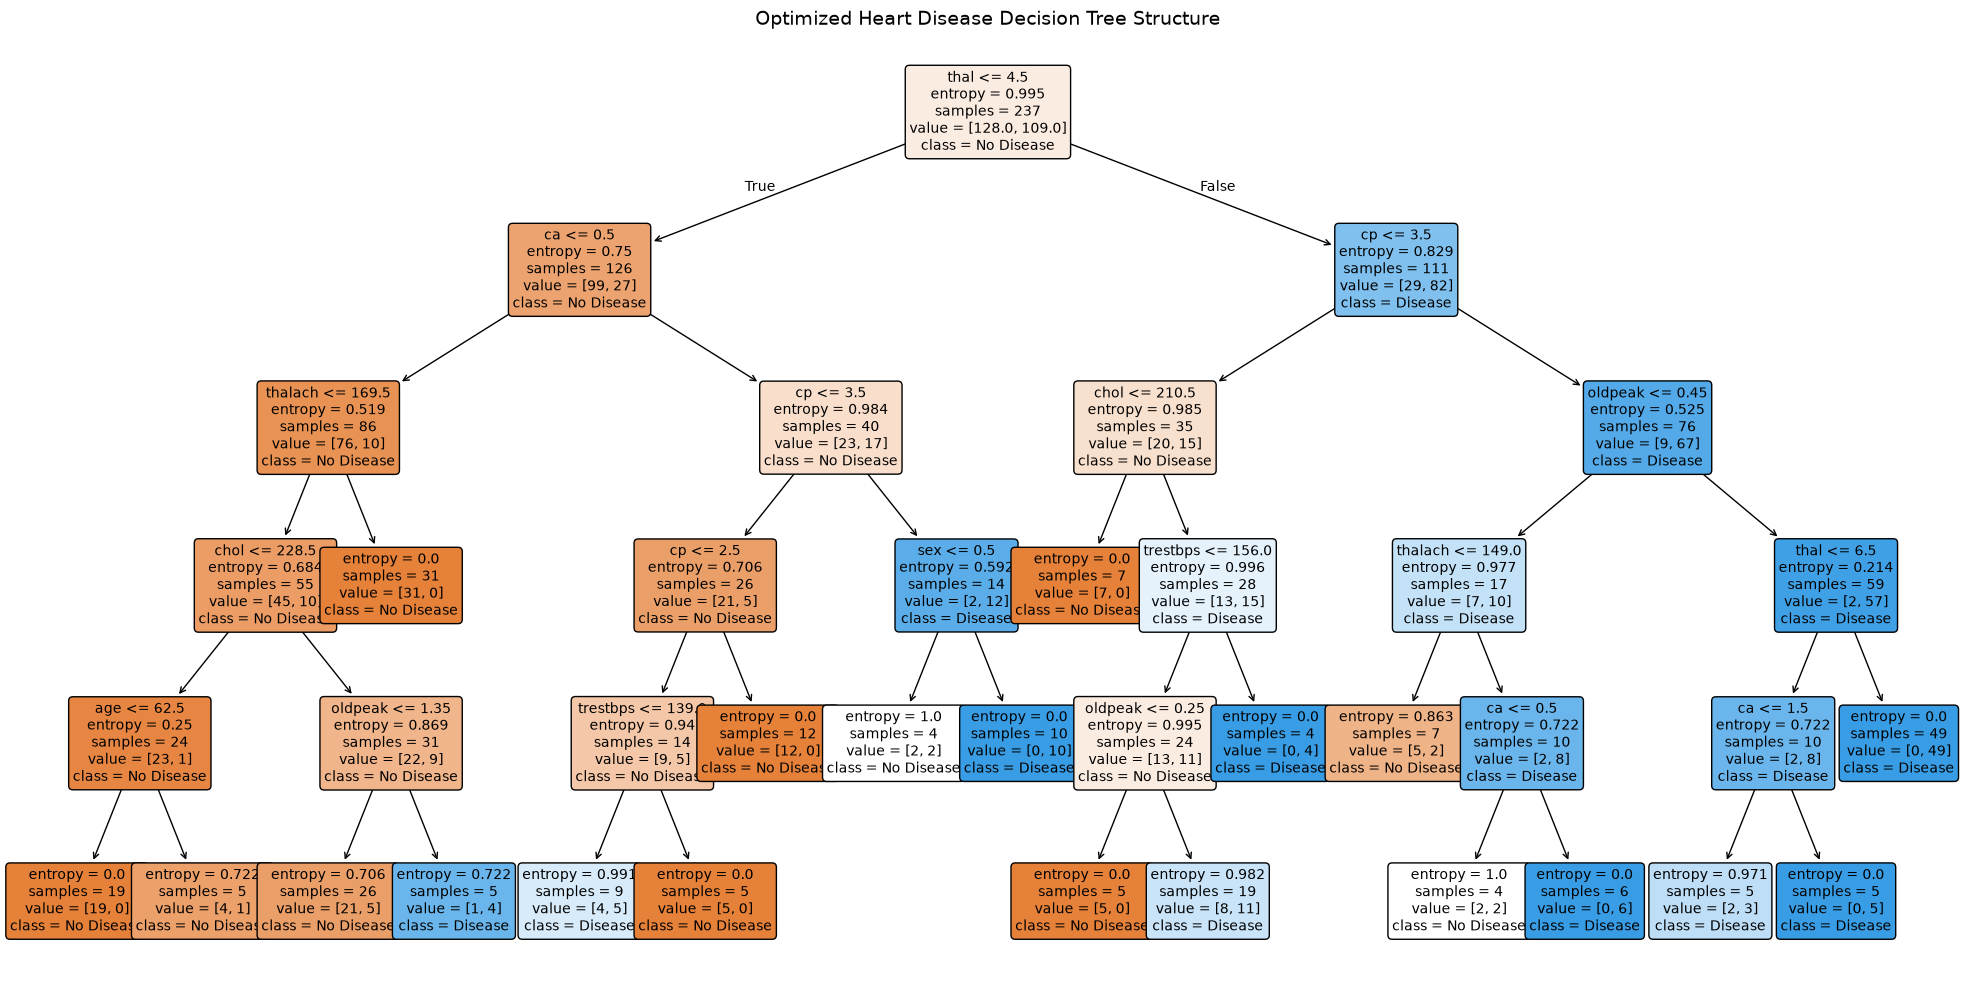

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model, 
    feature_names=X.columns, 
    class_names=['No Disease', 'Disease'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Optimized Heart Disease Decision Tree Structure", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\aceec\AppData\Local\Temp\ipykernel_8356\3983001939.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


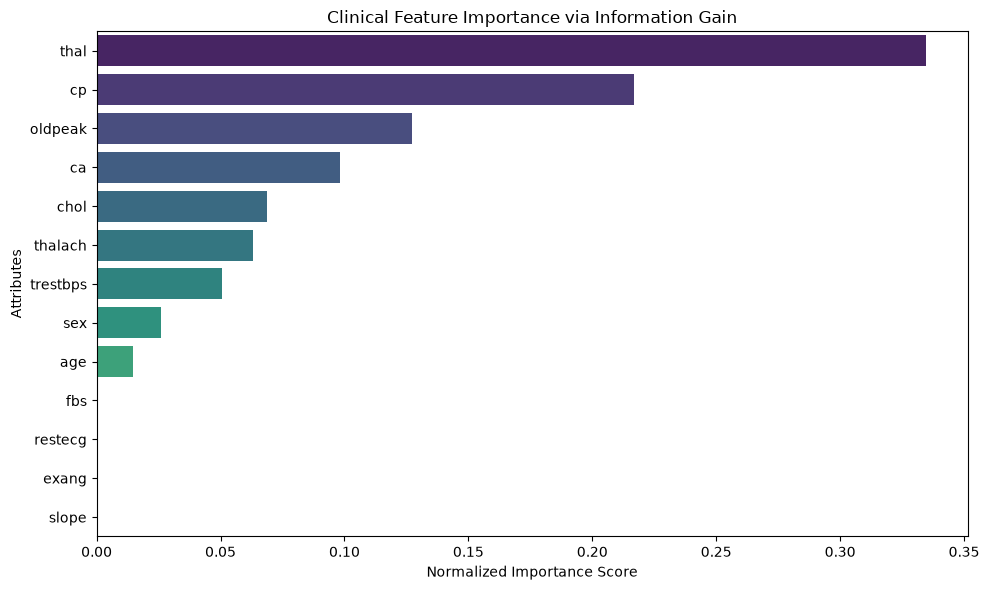

Feature Importance Ranking:
 Feature  Importance
    thal    0.334790
      cp    0.216743
 oldpeak    0.127323
      ca    0.098188
    chol    0.068771
 thalach    0.063047
trestbps    0.050423
     sex    0.026143
     age    0.014572
     fbs    0.000000
 restecg    0.000000
   exang    0.000000
   slope    0.000000


In [9]:
importances = best_dt_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Clinical Feature Importance via Information Gain')
plt.xlabel('Normalized Importance Score')
plt.ylabel('Attributes')
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
print(feature_importance_df.to_string(index=False))